<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ вакансий из HeadHunter
   

In [16]:
import pandas as pd
import psycopg2

import warnings
warnings.filterwarnings('ignore')

In [17]:
DBNAME = ''
USER = ''
PASSWORD = ''
HOST = ''
PORT = 5432

In [18]:
connection = psycopg2.connect(
    dbname=DBNAME,
    user=USER,
    host=HOST,
    password=PASSWORD,
    port=PORT
)

# Юнит 3. Предварительный анализ данных

1. Напишите запрос, который посчитает количество вакансий в нашей базе (вакансии находятся в таблице vacancies). 

2. Напишите запрос, который посчитает количество работодателей (таблица employers). 

3. Посчитате с помощью запроса количество регионов (таблица areas).

4. Посчитате с помощью запроса количество сфер деятельности в базе (таблица industries).

In [19]:
tables = ['vacancies','employers', 'areas', 'industries']
for table in tables:
    count = pd.read_sql(f'SELECT COUNT(*) FROM {table};', connection).iloc[0, 0]
    print(f'Количество {table}: {count}')

Количество vacancies: 49197
Количество employers: 23501
Количество areas: 1362
Количество industries: 294


***

В выборке присутствует 49 197 вакансий от 23 501 уникального работодателя, распределённых по 1 362 регионам и 294 отраслям.

Среднее количество вакансий на одного работодателя – около 2,1. Это говорит о том, что большинство компаний публикуют 1–2 вакансии (вероятно, точечный найм), и лишь небольшое число крупных игроков формируют большое количество предложений.

Огромное число регионов (1 362) при относительно небольшом объёме вакансий указывает на сильную территориальную фрагментацию. Однако впоследствии выяснится, что большая часть вакансий сконцентрирована в нескольких десятках городов, а большинство регионов практически не представлены.

# Юнит 4. Детальный анализ вакансий

1. Напишите запрос, который позволит узнать, сколько (cnt) вакансий в каждом регионе (area).
Отсортируйте по количеству вакансий в порядке убывания.

In [20]:
query4_1 = '''
    SELECT 
        a.name,
        COUNT(v.id) AS cnt
    FROM vacancies v
    JOIN areas a ON v.area_id = a.id
    GROUP BY a.id
    ORDER BY cnt DESC;
'''

In [21]:
print(f'Количество вакансий в каждом регионе: \n{pd.read_sql(query4_1, connection)}')

Количество вакансий в каждом регионе: 
                         name   cnt
0                      Москва  5333
1             Санкт-Петербург  2851
2                       Минск  2112
3                 Новосибирск  2006
4                      Алматы  1892
..                        ...   ...
764                    Кизляр     1
765                    Джизак     1
766                    Эртиль     1
767                  Арсеньев     1
768  Тура (Красноярский край)     1

[769 rows x 2 columns]


2. Напишите запрос, чтобы определить у какого количества вакансий заполнено хотя бы одно из двух полей с зарплатой.

In [22]:
query4_2 = '''
    SELECT COUNT(*)
    FROM vacancies
    WHERE COALESCE(salary_from, salary_to) IS NOT NULL;
'''

In [23]:
print(f'У какого количества вакансий заполнено хотя бы одно из двух полей с зарплатой: '
      f'{pd.read_sql(query4_2, connection).iloc[0, 0]}')

У какого количества вакансий заполнено хотя бы одно из двух полей с зарплатой: 24073


3. Найдите средние значения для нижней и верхней границы зарплатной вилки. Округлите значения до целого.

In [24]:
query4_3 = '''
    SELECT
        ROUND(AVG(salary_to), 0) AS avg_salary_to,
        ROUND(AVG(salary_from), 0) AS avg_salary_from
    FROM vacancies;
'''

In [25]:
result = pd.read_sql(query4_3, connection)
print(f'Среднее значение для нижней границы зарплаты: {result.iloc[0, 1]}\n'
      f'Среднее значение для верхней границы зарплаты: {result.iloc[0, 0]}')

Среднее значение для нижней границы зарплаты: 71065.0
Среднее значение для верхней границы зарплаты: 110537.0


4. Напишите запрос, который выведет количество вакансий для каждого сочетания типа рабочего графика (schedule) и типа трудоустройства (employment), используемого в вакансиях. Результат отсортируйте по убыванию количества.


In [26]:
query4_4 = '''
    SELECT 
        v.schedule, 
        v.employment, 
        COUNT(v.id) AS cnt
    FROM vacancies v
    GROUP BY schedule, employment
    ORDER BY cnt DESC;
'''

In [27]:
print(f'Количество вакансий для каждого сочетания типа рабочего графика:\n'
      f'{pd.read_sql(query4_4, connection)}')

Количество вакансий для каждого сочетания типа рабочего графика:
            schedule           employment    cnt
0        Полный день     Полная занятость  35367
1   Удаленная работа     Полная занятость   7802
2      Гибкий график     Полная занятость   1593
3   Удаленная работа  Частичная занятость   1312
4     Сменный график     Полная занятость    940
5        Полный день           Стажировка    569
6     Вахтовый метод     Полная занятость    367
7        Полный день  Частичная занятость    347
8      Гибкий график  Частичная занятость    312
9        Полный день     Проектная работа    141
10  Удаленная работа     Проектная работа    133
11     Гибкий график           Стажировка    116
12    Сменный график  Частичная занятость    101
13  Удаленная работа           Стажировка     64
14     Гибкий график     Проектная работа     18
15    Сменный график           Стажировка     12
16    Вахтовый метод     Проектная работа      2
17    Сменный график     Проектная работа      1


5. Напишите запрос, выводящий значения поля Требуемый опыт работы (experience) в порядке возрастания количества вакансий, в которых указан данный вариант опыта. 

In [28]:
query4_5 = '''
    SELECT 
        v.experience, 
        COUNT(v.id) AS cnt
    FROM vacancies v
    GROUP BY v.experience
    ORDER BY cnt ASC;
'''

In [29]:
print(f'Требуемый опыт работы в порядке возрастания количества вакансий:\n'
      f'{pd.read_sql(query4_5, connection)}')

Требуемый опыт работы в порядке возрастания количества вакансий:
           experience    cnt
0         Более 6 лет   1337
1           Нет опыта   7197
2       От 3 до 6 лет  14511
3  От 1 года до 3 лет  26152


***

Детальный анализ вакансий
1. Географическая концентрация:
* Топ-5 регионов (Москва, Санкт-Петербург, Минск, Новосибирск, Алматы) содержат ≈28% всех вакансий.
* Москва – абсолютный лидер (5 333 вакансии), далее Санкт-Петербург (2 851).
* 43,6% регионов не имеют ни одной вакансии, и только 162 региона имеют более 20 вакансий.

Рынок труда экстремально неравномерен. Основной спрос на сотрудников сосредоточен в столицах и крупнейших городах-миллионниках. Это типично для IT и смежных сфер: бизнес предпочитает открывать офисы и нанимать персонал в локациях с развитой инфраструктурой, высокой концентрацией квалифицированных кадров и доступом к инвесторам.

2. Зарплаты:
* Лишь около 50% вакансий содержат зарплатную вилку.
* Средняя нижняя граница – 71 065 руб., средняя верхняя – 110 537 руб.

Разрыв между нижней и верхней границей составляет около 40 тыс. руб., что даёт кандидату пространство для торга. Однако отсутствие зарплаты в половине вакансий – проблема для соискателя и усложняет анализ рынка. Компании, вероятно, сознательно скрывают вилку, чтобы не отпугнуть дорогих кандидатов или иметь возможность предложить меньше.

3. График и занятость:
* «Полный день + Полная занятость» – 72% вакансий.
* «Удалённая работа + Полная занятость» – 16%.
* Остальные форматы (гибкий/сменный/вахтовый график, частичная занятость, стажировка, проект) – лишь 12%.

Классический офисный формат доминирует, но удалёнка уже составляет существенную долю (16% от всех вакансий). Это подтверждает постпандемийный тренд: многие компании закрепили удалённый режим как норму. При этом гибкие и неполные занятости остаются нишевыми – рынок по‑прежнему ориентирован на «стандартного» сотрудника с рабочим днём 5/2.
  
4. Требуемый опыт работы:
* 1–3 года – 53% вакансий
* 3–6 лет – 29,5%
* Без опыта – 14,6%
* Более 6 лет – 2,7%

Рынок нацелен на middle (1–3 года) и strong middle (3–6 лет). Junior‑специалистам без опыта вход возможен, но конкуренция за эти 14,6% вакансий высока. Senior‑позиций (6+ лет) крайне мало – это либо узкие ниши, либо компании предпочитают растить «своих» сеньоров из внутреннего кадрового резерва.

# Юнит 5. Анализ работодателей

1. Напишите запрос, который позволит узнать, какие работодатели находятся на первом и пятом месте по количеству вакансий.

In [30]:
query5_1 = '''
    SELECT 
        e.name, 
        COUNT(v.id) AS cnt
    FROM vacancies v
    JOIN employers e ON v.employer_id = e.id
    GROUP BY e.id
    ORDER BY cnt DESC
    LIMIT 5;
'''

In [31]:
print(f'Таблица количества вакансий у работодателей:\n'
      f'{pd.read_sql(query5_1, connection)}')

Таблица количества вакансий у работодателей:
            name   cnt
0         Яндекс  1933
1     Ростелеком   491
2       Тинькофф   444
3           СБЕР   428
4  Газпром нефть   331


2. Напишите запрос, который для каждого региона выведет количество работодателей и вакансий в нём.
Среди регионов, в которых нет вакансий, найдите тот, в котором наибольшее количество работодателей.


In [32]:
query5_2 = '''
    WITH emp_by_area AS (
        SELECT 
            e.area, 
            COUNT(*) AS e_cnt
        FROM employers e
        GROUP BY e.area
    ),
    vac_by_area AS (
        SELECT 
            v.area_id, 
            COUNT(*) AS v_cnt
        FROM vacancies v
        GROUP BY v.area_id
    )
    SELECT 
        a.name,
        COALESCE(emp_by_area.e_cnt, 0) AS e_cnt,
        COALESCE(vac_by_area.v_cnt, 0) AS v_cnt
    FROM areas a
    LEFT JOIN emp_by_area ON a.id = emp_by_area.area
    LEFT JOIN vac_by_area ON a.id = vac_by_area.area_id
    WHERE v_cnt IS NULL
    ORDER BY COALESCE(emp_by_area.e_cnt, 0) DESC, a.id;
'''

In [33]:
print(f'Таблица количества вакансий и работадателей по регионам:\n'
      f'{pd.read_sql(query5_2, connection)}')

Таблица количества вакансий и работадателей по регионам:
                              name  e_cnt  v_cnt
0                           Россия    410      0
1                        Казахстан    207      0
2               Московская область     75      0
3               Краснодарский край     19      0
4                         Беларусь     18      0
..                             ...    ...    ...
588                       Песчаное      0      0
589                    Усть-Абакан      0      0
590  Белый Яр (Республика Хакасия)      0      0
591    Андреевка (Хасанский район)      0      0
592                  Верхневилюйск      0      0

[593 rows x 3 columns]


3. Для каждого работодателя посчитайте количество регионов, в которых он публикует свои вакансии. Отсортируйте результат по убыванию количества.


In [34]:
query5_3 = '''
    SELECT 
        e.name,
        COUNT(DISTINCT v.area_id) AS cnt
    FROM employers e
    LEFT JOIN vacancies v ON e.id = v.employer_id
    GROUP BY e.id
    ORDER BY cnt DESC;
'''

In [35]:
print(f'Таблица количества регионов по работодателям:\n'
      f'{pd.read_sql(query5_3, connection)}')

Таблица количества регионов по работодателям:
                         name  cnt
0                      Яндекс  181
1                  Ростелеком  152
2                  Спецремонт  116
3      Поляков Денис Иванович   88
4                   ООО ЕФИН    71
...                       ...  ...
23496              Но Смокинг    0
23497        МАСТЕРСКАЯ CREED    0
23498           Dzing Finance    0
23499                    КОРС    0
23500             Наука-Связь    0

[23501 rows x 2 columns]


4. Напишите запрос для подсчёта количества работодателей, у которых не указана сфера деятельности. 

In [36]:
query5_4 = '''
    SELECT 
    	COUNT(*)
    FROM employers e
    LEFT JOIN employers_industries ei ON ei.employer_id = e.id
    WHERE ei.employer_id IS NULL;
'''

In [37]:
print(f'Количество работодателей, у которых не указана сфера деятельности: '
      f'{pd.read_sql(query5_4, connection).iloc[0, 0]}')

Количество работодателей, у которых не указана сфера деятельности: 8419


5. Напишите запрос, чтобы узнать название компании, находящейся на третьем месте в алфавитном списке (по названию) компаний, у которых указано четыре сферы деятельности. 

In [38]:
query5_5 = '''
    SELECT 
        e.name,
        COUNT(ei.employer_id) AS cnt
    FROM employers e
    LEFT JOIN employers_industries ei ON ei.employer_id = e.id
    GROUP BY e.id
    HAVING COUNT(ei.employer_id) = 4
    ORDER BY e.name;
'''

In [39]:
print(f'Название компании, находящейся на третьем месте в алфавитном списке (по названию) компаний, у которых указано четыре сферы деятельности.:\n'
      f'{pd.read_sql(query5_5, connection).iloc[2, 0]}')

Название компании, находящейся на третьем месте в алфавитном списке (по названию) компаний, у которых указано четыре сферы деятельности.:
2ГИС


6. С помощью запроса выясните, у какого количества работодателей в качестве сферы деятельности указана Разработка программного обеспечения.


In [40]:
query5_6 = '''
    SELECT 
    	COUNT(DISTINCT e.id) AS cnt
    FROM employers e
    JOIN employers_industries ei ON ei.employer_id = e.id
    JOIN industries i ON ei.industry_id = i.id
    WHERE i.name = 'Разработка программного обеспечения'
'''

In [41]:
print(f'Количество работодателей в качестве сферы деятельности указана - Разработка программного обеспечения.:\n'
      f'{pd.read_sql(query5_6, connection).iloc[0, 0]}')

Количество работодателей в качестве сферы деятельности указана - Разработка программного обеспечения.:
3553


7. Для компании «Яндекс» выведите список регионов-миллионников, в которых представлены вакансии компании, вместе с количеством вакансий в этих регионах. Также добавьте строку Total с общим количеством вакансий компании. Результат отсортируйте по возрастанию количества.

Список городов-милионников надо взять [отсюда](https://ru.wikipedia.org/wiki/%D0%93%D0%BE%D1%80%D0%BE%D0%B4%D0%B0-%D0%BC%D0%B8%D0%BB%D0%BB%D0%B8%D0%BE%D0%BD%D0%B5%D1%80%D1%8B_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8). 

Если возникнут трудности с этим задание посмотрите материалы модуля  PYTHON-17. Как получать данные из веб-источников и API. 

In [42]:
!pip install beautifulsoup4

In [43]:
import requests
from bs4 import BeautifulSoup

def get_million_cities() -> list[str]:
    """Возвращает список городов-миллионников России с Wikipedia."""
    url = 'https://ru.wikipedia.org/wiki/Города-миллионеры_России'
    headers = {'User-Agent': 'Mozilla/5.0'}

    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, 'html.parser')

    # Ищем основную таблицу с классом standard
    table = soup.find('table', class_='standard')
    if not table:
        raise ValueError('Не удалось найти таблицу с городами на странице Wikipedia')

    cities = []
    # Пропускаем первую строку с заголовками
    # Из каждой строки берём вторую <td>, внутри которой <a title="Город">.
    for row in table.find_all('tr')[1:]:
        cells = row.find_all('td')
        if len(cells) < 2:
            continue
        a = cells[1].find('a')
        if a and a.get('title'):
            cities.append(a['title'])

    return cities


cities = get_million_cities()
placeholders = ', '.join([f"'{city}'" for city in cities])

In [44]:
query5_7 = f'''
    SELECT 
        COALESCE(a.name, 'Total') AS name,
        COUNT(v.id) AS cnt
    FROM employers e
    JOIN vacancies v ON e.id = v.employer_id
    JOIN areas a ON v.area_id = a.id
    WHERE e.name = 'Яндекс'
      AND a.name IN ({placeholders})
    GROUP BY ROLLUP(a.name)
    ORDER BY 
        CASE WHEN a.name IS NULL THEN 1 ELSE 0 END,  -- Total внизу
        cnt ASC,
        a.name;
'''

In [45]:
print(f'Города миллионники: {cities}')
print(f'Cписок регионов-миллионников, в которых представлены вакансии компании Яндекс:\n'
    f'{pd.read_sql(query5_7, connection)}')

Города миллионники: ['Москва', 'Санкт-Петербург', 'Новосибирск', 'Екатеринбург', 'Казань', 'Красноярск', 'Нижний Новгород', 'Челябинск', 'Уфа', 'Краснодар', 'Самара', 'Ростов-на-Дону', 'Омск', 'Воронеж', 'Пермь', 'Волгоград']
Cписок регионов-миллионников, в которых представлены вакансии компании Яндекс:
               name  cnt
0              Омск   21
1         Челябинск   22
2        Красноярск   23
3         Волгоград   24
4            Казань   25
5             Пермь   25
6    Ростов-на-Дону   25
7            Самара   26
8               Уфа   26
9         Краснодар   30
10          Воронеж   32
11      Новосибирск   35
12  Нижний Новгород   36
13     Екатеринбург   39
14  Санкт-Петербург   42
15           Москва   54
16            Total  485


***

Анализ работодателей
1. Концентрация вакансий у крупнейших работодателей:
* Яндекс публикует 1933 вакансии из 49 197, что составляет 3,93% от всех вакансий.
* Суммарная доля топ-5 (Яндекс + Ростелеком + Тинькофф + СБЕР + Газпром нефть) ~ 7,37%.
* Рынок не является гиперконцентрированным, но "Яндекс" заметно выделяется.
  
Это говорит о здоровой конкурентной среде, где множество средних и малых компаний предлагают работу.

2. Географическое присутствие:
* Яндекс охватывает 181 регион из 1362 (13,3%). Это максимальное значение среди всех работодателей.
* Ростелеком – 152 региона (11,2%), Спецремонт – 116 (8,5%) и.т.п.
* При этом большинство работодателей присутствуют лишь в 1–2 регионах

Крупные технологические и телеком‑компании активно расширяют географию найма, открывая удалённые или гибридные позиции по всей стране. Это даёт соискателям из малых городов доступ к высокооплачиваемым проектам.

3. Сферы деятельности:
* «Разработка ПО» указана у 3 553 работодателей (15,1% от всех).
* 8 419 работодателей (35,8%) не указали сферу – серьёзное пропущенное значение, искажающее отраслевой анализ.

Даже с учётом пропусков, IT‑сфера составляет большую долю вакансий. Можно предположить, что среди не указавших сферу также много IT‑компаний (особенно небольших стартапов и аутсорсеров), которые не заполняют справочник.

4. Города-миллионники и Яндекс:
* Во всех 16 городах-миллионниках есть вакансии Яндекса, суммарно 485 вакансий (25,1% от всех вакансий Яндекса). Остальные 74,9% приходятся на другие регионы.
  
Яндекс активно использует распределённую модель найма – большинство его вакансий открыты за пределами крупнейших городов. Это выгодно и компании (доступ к более широкому пулу кадров, возможность снижения затрат на офисы), и соискателям из регионов.

В Москве число уникальных работодателей (5 864) превышает число вакансий (5 333). Это возможно, если многие московские компании зарегистрированы в столице, но публикуют вакансии для других регионов (удалёнка или филиалы). Либо часть работодателей в данный момент не ведёт активный найм, но числится в базе.

# Юнит 6. Предметный анализ

1. Сколько вакансий имеет отношение к данным?

Считаем, что вакансия имеет отношение к данным, если в её названии содержатся слова 'data' или 'данн'.

*Подсказка: Обратите внимание, что названия вакансий могут быть написаны в любом регистре.* 


In [46]:
query6_1 = '''
    SELECT
    	COUNT(*)
    FROM vacancies v
    WHERE lower(v.name) LIKE '%data%'
      OR lower(v.name) LIKE '%данн%'
'''

In [47]:
print(f'Количество вакансий, которые имеют отношение к данным:\n'
    f'{pd.read_sql(query6_1, connection).iloc[0, 0]}')

Количество вакансий, которые имеют отношение к данным:
1771


2. Сколько есть подходящих вакансий для начинающего дата-сайентиста? 
Будем считать вакансиями для дата-сайентистов такие, в названии которых есть хотя бы одно из следующих сочетаний:
* 'data scientist'
* 'data science'
* 'исследователь данных'
* 'ML' (здесь не нужно брать вакансии по HTML)
* 'machine learning'
* 'машинн%обучен%'

** В следующих заданиях мы продолжим работать с вакансиями по этому условию.*

Считаем вакансиями для специалистов уровня Junior следующие:
* в названии есть слово 'junior' *или*
* требуемый опыт — Нет опыта *или*
* тип трудоустройства — Стажировка.
 

In [48]:
query6_2 = '''
    CREATE OR REPLACE VIEW ds
    AS
    SELECT *
    FROM vacancies v
    WHERE (
    		lower(v.name) LIKE '%data scientist%'
    		OR lower(v.name) LIKE '%data science%'
    		OR lower(v.name) LIKE '%исследователь данных%'
    		OR (v.name LIKE '%ML%' AND v.name NOT LIKE '%HTML%')
    		OR lower(v.name) LIKE '%machine learning%'
    		OR lower(v.name) LIKE '%машинн%обучен%%'
    );
    SELECT COUNT(*)
    FROM ds
    WHERE (
        lower(ds.name) LIKE '%junior%'
        OR ds.experience = 'Нет опыта'
        OR ds.employment = 'Стажировка'
    )
'''

In [49]:
print(f'Количество подходящих вакансий для начинающего дата-сайентиста:\n'
    f'{pd.read_sql(query6_2, connection).iloc[0, 0]}')

Количество подходящих вакансий для начинающего дата-сайентиста:
51


3. Сколько есть вакансий для DS, в которых в качестве ключевого навыка указан SQL или postgres?

** Критерии для отнесения вакансии к DS указаны в предыдущем задании.*

In [50]:
query6_3 = '''
    SELECT
        COUNT(*)
    FROM ds
    WHERE (
    	lower(ds.key_skills) LIKE '%sql%'
        OR lower(ds.key_skills) LIKE '%postgres%'
    	)
'''

In [51]:
print(f'Количество вакансий для DS(SQL, postgres):\n'
    f'{pd.read_sql(query6_3, connection).iloc[0, 0]}')

Количество вакансий для DS(SQL, postgres):
201


4. Проверьте, насколько популярен Python в требованиях работодателей к DS.Для этого вычислите количество вакансий, в которых в качестве ключевого навыка указан Python.

** Это можно сделать помощью запроса, аналогичного предыдущему.*

In [52]:
query6_4 = '''
    SELECT
        COUNT(*)
    FROM ds
    WHERE lower(ds.key_skills) LIKE '%python%'
'''

In [53]:
print(f'Количество вакансий для DS(SQL, postgres):\n'
    f'{pd.read_sql(query6_4, connection).iloc[0, 0]}')

Количество вакансий для DS(SQL, postgres):
351


5. Сколько ключевых навыков в среднем указывают в вакансиях для DS?
Ответ округлите до двух знаков после точки-разделителя.

In [54]:
query6_5 = '''
    SELECT
    	ROUND(AVG(LENGTH(ds.key_skills) - LENGTH(REPLACE(ds.key_skills, chr(9), '')) + 1), 2)
    FROM ds;
'''

In [55]:
print(f'Количество ключевых навыков в среднем указывают в вакансиях для DS:\n'
    f'{pd.read_sql(query6_5, connection).iloc[0, 0]}')

Количество ключевых навыков в среднем указывают в вакансиях для DS:
6.41


6. Напишите запрос, позволяющий вычислить, какую зарплату для DS в **среднем** указывают для каждого типа требуемого опыта (уникальное значение из поля *experience*). 

При решении задачи примите во внимание следующее:
1. Рассматриваем только вакансии, у которых заполнено хотя бы одно из двух полей с зарплатой.
2. Если заполнены оба поля с зарплатой, то считаем зарплату по каждой вакансии как сумму двух полей, делённую на 2. Если заполнено только одно из полей, то его и считаем зарплатой по вакансии.
3. Если в расчётах участвует null, в результате он тоже даст null (посмотрите, что возвращает запрос select 1 + null). Чтобы избежать этой ситуацию, мы воспользуемся функцией [coalesce](https://postgrespro.ru/docs/postgresql/9.5/functions-conditional#functions-coalesce-nvl-ifnull), которая заменит null на значение, которое мы передадим. Например, посмотрите, что возвращает запрос `select 1 + coalesce(null, 0)`

Выясните, на какую зарплату в среднем может рассчитывать дата-сайентист с опытом работы от 3 до 6 лет. Результат округлите до целого числа. 

In [56]:
query6_6 = '''
    SELECT
        ds.experience,
        ROUND(AVG(COALESCE((salary_from + salary_to) / 2.0, salary_from, salary_to)), 0) AS salary
    FROM ds
    WHERE COALESCE(ds.salary_from, ds.salary_to) IS NOT NULL
    GROUP BY ds.experience;
'''

In [57]:
print(f'Средняя заоплата DS с опытом работы от 3 до 6 лет:\n'
    f'{pd.read_sql(query6_6, connection)}')

Средняя заоплата DS с опытом работы от 3 до 6 лет:
           experience    salary
0           Нет опыта   74643.0
1  От 1 года до 3 лет  139675.0
2       От 3 до 6 лет  243115.0


***

1. Объём рынка DS:
* 1 771 вакансия имеют отношение к данным – это 3,6% от всех вакансий. Доля небольшая, но абсолютное число значительное.
* Подходящих для начинающего (Junior) дата-сайентиста – всего 51 вакансия из общего количества DS - 480.
* С требованием SQL/postgres – 201 вакансия.

Рынок DS уже сформирован, но вход для новичков крайне труден. Соотношение Junior : Middle+ примерно 1:10. Компании предпочитают нанимать уже опытных специалистов, способных сразу вести проекты. Начинающим дата-сайентистам стоит либо набираться опыта через стажировки, либо смещаться в смежные роли.

2. Ключевые навыки: Среднее количество упоминаемых навыков в DS‑вакансиях – 6,41. Это говорит о высоких требованиях к широте стека.
3. Зарплаты по опыту (DS):
* Нет опыта → 74 643 руб.
* 1–3 года → 139 675 руб. (рост в 1,87 раза)
* 3–6 лет → 243 115 руб. (рост ещё в 1,74 раза)

Зарплата DS растёт с опытом почти экспоненциально. Уже через 1–3 года специалист зарабатывает в среднем 140 тыс., а через 3–6 лет – 243 тыс. Это один из самых быстрорастущих по доходу профилей на рынке. Однако важно понимать, что средние значения могут быть завышены из-за выбросов (крупные компании в Москве), и реальные цифры по регионам могут отличаться.

# Общий вывод по проекту

1. Каких вакансий много?

На рынке доминируют позиции, требующие опыта от 1 года до 3 лет (более половины всех вакансий). Самый популярный формат работы – полный день + полная занятость (72%). По отраслям лидирует разработка программного обеспечения, а среди работодателей выделяется Яндекс (около 4% всех вакансий). Вакансий, связанных с данными (Data Science), около 3,6% – это уже состоявшаяся, но не массовая ниша.

3. Рынок труда в различных городах

Крайняя неравномерность: Москва и Санкт-Петербург собирают львиную долю предложений. В то же время крупные технологические компании (Яндекс, Ростелеком) активно расширяют присутствие в регионах, предлагая удалённую работу. Это постепенно выравнивает возможности для соискателей из малых городов. Однако местные рынки (без учёта удалёнки) остаются слаборазвитыми – более 40% регионов не имеют ни одной вакансии.

5. Интересные наблюдения
* Зарплатная вилка указывается только в половине вакансий, что снижает прозрачность рынка.
* Удалённая работа уверенно заняла 16% – тренд, который, вероятно, сохранится.
* Junior-специалистам сложно: на рынке DS всего 51 вакансия для начинающих, а в целом по рынку только 14,6% вакансий не требуют опыта.
* Работодатели с широкой географией (Яндекс, Ростелеком) создают «единое пространство вакансий»

4. Дополнительные исследования, которые можно провести
* Географическая кластеризация регионов по уровню заработных плат и активности работодателей
* Прогнозирование спроса на DS-специалистов на основе роста упоминания технологий
* Исследование причин пропуска зарплат


5. Прогноз:
Рынок продолжит смещаться в сторону удалённых и гибридных форматов. Конкуренция за Junior-позиции останется высокой, а спрос на Middle+ DS будет расти на 15–20% в год. Региональное неравенство начнёт сглаживаться благодаря компаниям, которые сознательно расширяют географию найма. 

В ходе анализа базы данных вакансий был выявлен ряд направлений для углублённого изучения рынка труда. Одним из таких направлений стала географическая кластеризация регионов по уровню заработных плат и активности работодателей. Для наглядной демонстрации различий между городами-миллионниками была построена интерактивная карта с пузырьковой диаграммой.

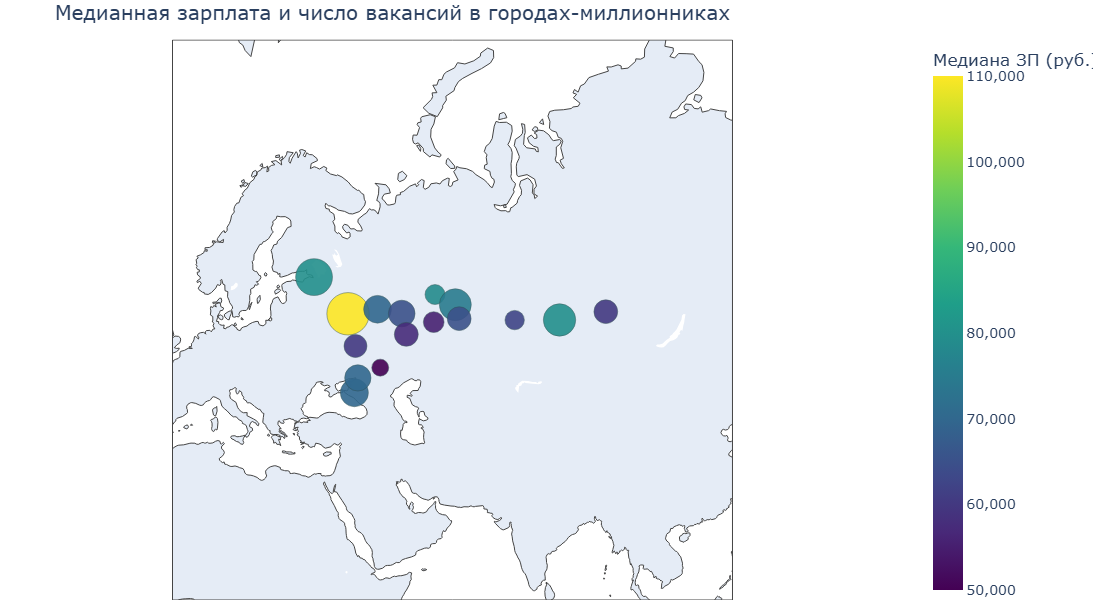

In [58]:
import plotly.express as px
import plotly.graph_objects as go

#SQL-запрос: медианная зарплата и число вакансий по регионам
query = '''
    SELECT 
        a.name AS region_name,
        COUNT(v.id) AS vacancy_count,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY 
            COALESCE((v.salary_from + v.salary_to) / 2.0, v.salary_from, v.salary_to)
        ) AS salary_median
    FROM vacancies v
    JOIN areas a ON v.area_id = a.id
    WHERE COALESCE(v.salary_from, v.salary_to) IS NOT NULL
    GROUP BY a.id, a.name
    ORDER BY salary_median DESC;
'''

df = pd.read_sql(query, connection)

#cities - из задния 5.7
df_filtered = df[df['region_name'].isin(cities)].copy()

#Координаты городов-миллионников
coords = {
    'Москва': (55.7558, 37.6173),
    'Санкт-Петербург': (59.9343, 30.3351),
    'Новосибирск': (55.0084, 82.9357),
    'Екатеринбург': (56.8389, 60.6057),
    'Казань': (55.7887, 49.1221),
    'Нижний Новгород': (56.2965, 43.9361),
    'Красноярск': (56.0106, 92.8526),
    'Челябинск': (55.1644, 61.4368),
    'Уфа': (54.7388, 55.9721),
    'Самара': (53.1959, 50.1002),
    'Ростов-на-Дону': (47.2357, 39.7155),
    'Омск': (54.9884, 73.3242),
    'Воронеж': (51.6755, 39.2089),
    'Пермь': (58.0105, 56.2502),
    'Волгоград': (48.7071, 44.5169),
    'Краснодар': (45.0355, 38.9753),
}

df_filtered['lat'] = df_filtered['region_name'].map(lambda x: coords.get(x, (None, None))[0])
df_filtered['lon'] = df_filtered['region_name'].map(lambda x: coords.get(x, (None, None))[1])
df_filtered = df_filtered.dropna(subset=['lat', 'lon'])

fig = px.scatter_geo(
    df_filtered,
    lat='lat',
    lon='lon',
    color='salary_median',
    size='vacancy_count',
    hover_name='region_name',
    projection='mercator',
    color_continuous_scale='Viridis',
    size_max=30,
    opacity=0.9
)
fig.update_traces(
    hovertemplate='<b>%{hovertext}</b><br>' +
                  'Медианная зарплата: %{marker.color:,.0f} руб.<br>' +
                  'Вакансий: %{marker.size:,}<extra></extra>',
    marker=dict(line=dict(width=0.5, color='DarkSlateGray'))
)

fig.update_layout(
    title='Медианная зарплата и число вакансий в городах-миллионниках',
    width=1090,
    height=600,
    font_size=14,
    title_font_size=20,
    coloraxis_colorbar=dict(
        title="Медиана ЗП (руб.)",
        tickformat=",.0f"
    ),
    margin={"r":0, "t":40, "l":0, "b":0},
    geo=dict(
        center=dict(lat=55, lon=60),
        projection_scale=3
    )
    
)

fig.show()

Ключевые выводы по графику:

1. Москва – абсолютный лидер по зарплате и объёму рынка. Медианная зарплата – 110 000 руб., число вакансий – 1592. Это почти вдвое больше, чем в любом другом городе.
2. Санкт-Петербург и Новосибирск образуют группу городов с медианной зарплатой 80 000 руб., при этом Петербург значительно превосходит Новосибирск по числу вакансий (1203 против 929). Это делает их привлекательной альтернативой для соискателей, не готовых к переезду в столицу, так как предлагают столько же возможностей при немного меньшей зарплате.
3. При скромном числе вакансий (352) Пермь показывает медианную зарплату 78 900 руб. Для узких специалистов Пермь может оказаться более выгодной, чем города с большей конкуренцией.
4. Волгоград – аутсайдер. Самая низкая медианная зарплата (50 000 руб.) и минимальное число вакансий (255). Волгоград заметно отстаёт даже от соседних миллионников.

Практическая значимость исследования:
* Соискатели могут оценить баланс «доход – количество предложений – стоимость жизни» и выбрать город для переезда или поиска удалённой работы.
* Работодатели видят, в каких городах высокая конкуренция за кадры (Москва, СПб), а где можно привлечь специалистов за меньшие деньги (Волгоград, Уфа).
* Аналитики рынка труда получают инструмент для мониторинга региональной дифференциации зарплат.